In [1]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.optimize import minimize
from smooth_POD_ROM.post_processing import post_process, richardson_lucy
from smooth_POD_ROM.post_processing import get_sigma
from smooth_POD_ROM.reduced_order_model import optimize_hyperparameters, optimize_hyperparameters_single, snapshots
from smooth_POD_ROM.pre_processing import convolve_f, gaussian_f, gaussian, smoothen
from smooth_POD_ROM.initial_conditions import rectangular_pulse, rect_pulse_sin, saw_tooth, triangle
from smooth_POD_ROM.reduced_order_model import delta_n_width, train_ROM, L2_error, zielfunktion
from smooth_POD_ROM.plots_paper import Fig3, Fig4, Fig5, Fig6, Fig7, Fig8, Fig11
import warnings
from scipy.ndimage import gaussian_filter
from scipy.signal import convolve2d as conv2
from scipy.interpolate._rgi_cython import evaluate_linear_2d, find_indices
from scipy.interpolate import (
    RegularGridInterpolator,
    RectBivariateSpline,
    interpn,
    griddata,
    Rbf,
    interp1d,
    interp2d,
)
from scipy.fft import fft, ifft, fftshift, ifftshift, fftfreq
from scipy.signal import wiener, butter, freqs, convolve, freqz
from scipy.signal import wiener
from scipy.ndimage import gaussian_filter1d
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd, orth, qr
from scipy.optimize import curve_fit
from numpy import sin, cos, pi


8.030570172000001


In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
page_width_pt = 455.24
pt2in = 0.01389 
pt2cm = 0.0352777778
cm2in = 1/2.54
page_width_cm = 13.70499
# TODO: work with textwidth
plot_width_in = page_width_pt*pt2in/2
page_width_in = page_width_cm*cm2in
print(plot_width_in/cm2in)

fs = 10
fs_lbl = 6
plt.rcParams["figure.figsize"] = (plot_width_in, plot_width_in/1.61803398875)
plt.rcParams["figure.autolayout"] = True
plt.rcParams['font.size'] = fs
plt.rcParams['axes.titlesize'] = fs
plt.rcParams['axes.labelsize'] = fs
plt.rcParams['xtick.labelsize'] = fs
plt.rcParams['ytick.labelsize'] = fs
plt.rcParams['legend.labelspacing'] = 0.0
plt.rcParams['legend.fontsize'] = fs_lbl
plt.rcParams['legend.handlelength'] = 1.0

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=fs, serif='Computer Modern Roman')
pth = "../Plots/"

markevery = 45

8.030570172000001


In [3]:
n_x = 1000
n_train = 50
n_test = 10
num_iter1 = 50
num_iter2 = 250
# num_iter3 = 1000
num_iter4 = 2500

In [4]:
rank = n_train
dx = 1 / n_x
shape = (n_x,)
clip = True

In [5]:
x = np.linspace(0, 1, n_x, endpoint=False)
mu_train = np.linspace([0.0], [1.0], n_train, endpoint=False)
mu_test = np.linspace(mu_train[1], mu_train[2], n_test, endpoint=False)

g = rectangular_pulse

X_train = snapshots(g, x, mu_train)
X_test = snapshots(g, x, mu_test)

In [6]:
# sigma, c = optimize_hyperparameters(x, mu_train, mu_test, X_train, X_test, shape, num_iter2, clip, rank)
rank, sigma, c = 10, 0.046817495544034825, 3.4777597632478527  # -77.5, num_iter2=250, n_test=10
rank, sigma, c = 20, 0.04709477073255084, 0.9473123624789438  # -64.5, num_iter2=250, n_test=10
rank, sigma, c = 50, 0.010637015820358114, 1.1437423194705931  # -53.5667, num_iter2=250, n_test=10

C:\Users\florianma\AppData\Local\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


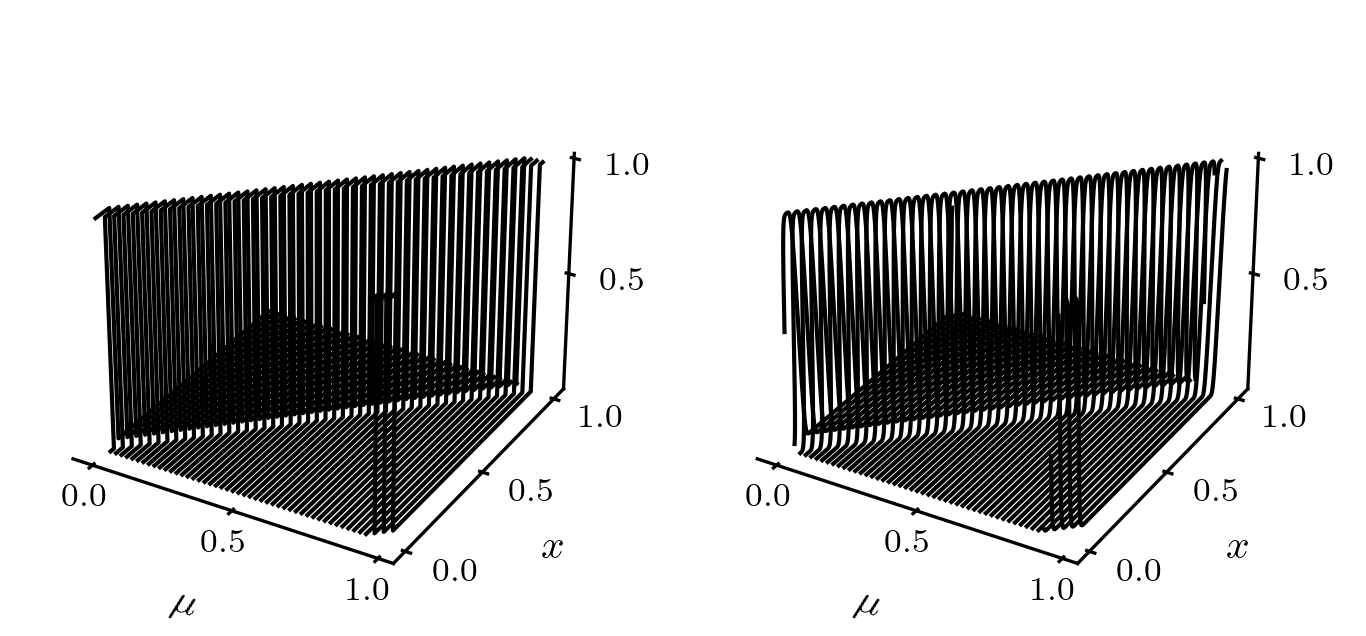

In [7]:
X_train_s = smoothen(X_train, sigma / dx, x.shape, truncate=12)
X_test_s = smoothen(X_test, sigma / dx, x.shape, truncate=12)

Fig3(x, mu_train, X_train, X_train_s)

20 0.0471 0.9473


C:\Users\florianma\AppData\Local\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


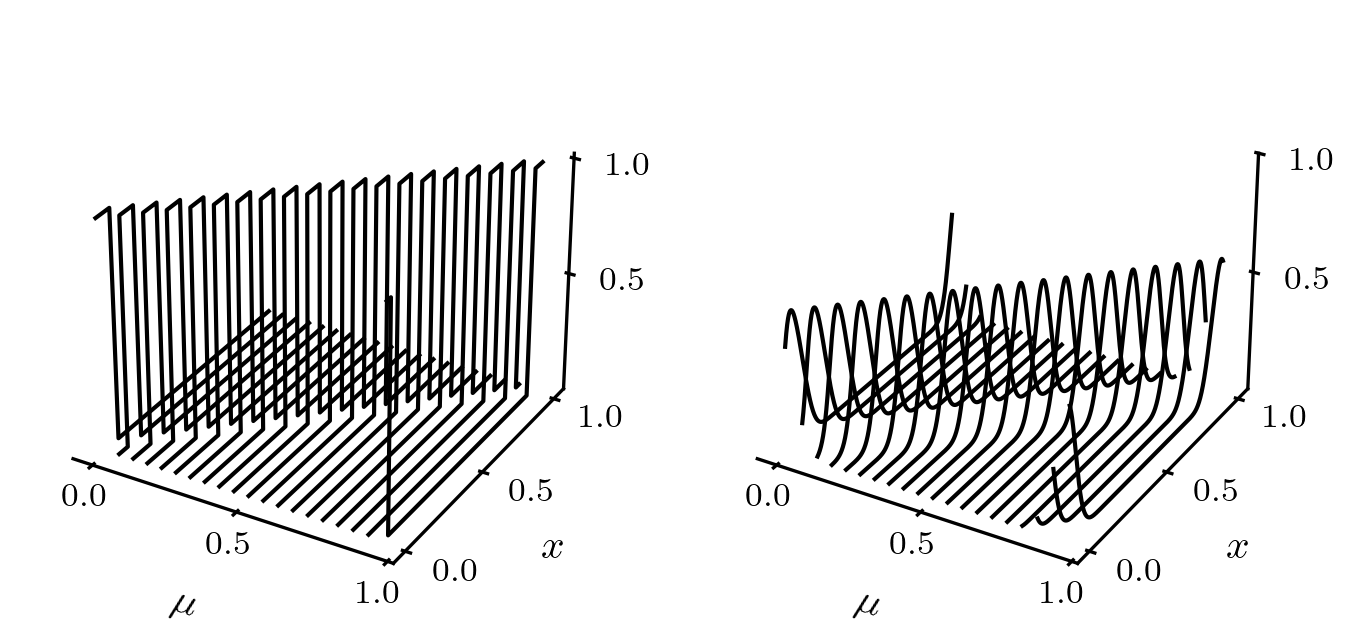

build ROM and predict
model performance validation
post_process: 0.0471 0.9473 50 (1000,) True


C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:33: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


post_process: 0.0471 0.9473 250 (1000,) True
0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, average improvement (50 iterations): 43.35
average improvement (250 iterations): 61.91


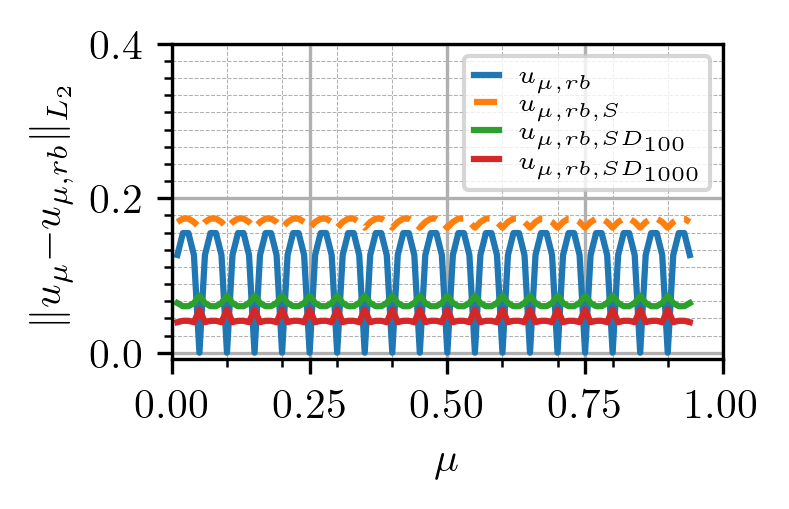

In [8]:
rank, sigma, c = 20, 0.0471, 0.9473

print(rank, sigma, c)
mu_train = np.linspace([0.0], [1.0], rank, endpoint=False)
X_train = snapshots(g, x, mu_train)
X_train_s = smoothen(X_train, sigma / dx, x.shape, truncate=12)

mu_val = x.copy()[::10]
interpolatable = (mu_train[0] < mu_val) & (mu_val < mu_train[-1])
mu_val = mu_val[interpolatable][:, None]
X_val = snapshots(g, x, mu_val)
X_val_s = smoothen(X_val, sigma / dx, x.shape, truncate=12)

Fig3(x, mu_train, X_train, X_train_s)

print("build ROM and predict")
standard_rom = train_ROM(mu_train, X_train, rank=rank)
smooth_rom = train_ROM(mu_train, X_train_s, rank=rank)
X_test_ROM = standard_rom.predict(mu_test).snapshots_matrix.T
X_val_ROM = standard_rom.predict(mu_val).snapshots_matrix.T
X_test_sROM = smooth_rom.predict(mu_test).snapshots_matrix.T
X_val_sROM = smooth_rom.predict(mu_val).snapshots_matrix.T


print("model performance validation")
X_val_sROMs = post_process(
    x, X_val_sROM, sigma, c, mu_val, mu_train, num_iter1, shape, clip=clip, progress=False
)
X_val_sROMs2 = post_process(
    x, X_val_sROM, sigma, c, mu_val, mu_train, num_iter2, shape, clip=clip, progress=True
)
eROM = L2_error(X_val_ROM, X_val)
esROM = L2_error(X_val_sROM, X_val)
esROMs = L2_error(X_val_sROMs, X_val)
esROMs2 = L2_error(X_val_sROMs2, X_val)
imp1 = 100 - np.mean(esROMs) / np.mean(eROM) * 100
imp2 = 100 - np.mean(esROMs2) / np.mean(eROM) * 100
print("average improvement ({:.0f} iterations): {:.2f}".format(num_iter1, imp1))
print("average improvement ({:.0f} iterations): {:.2f}".format(num_iter2, imp2))

Fig6(mu_val, eROM, esROM, esROMs, esROMs2)

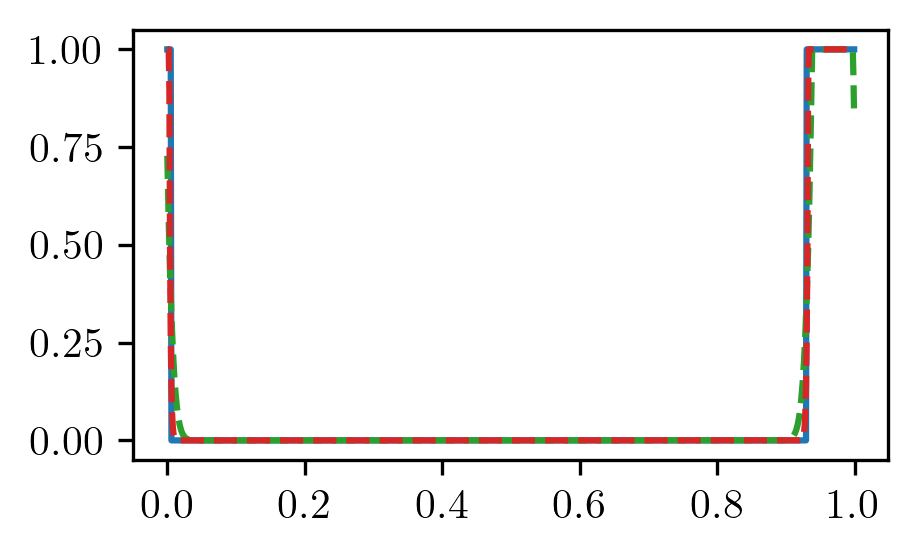

In [9]:
# eROM = L2_error(X_val_ROM, X_val)
# esROM = L2_error(X_val_sROM, X_val)
# esROMs = L2_error(X_val_sROMs, X_val)
# esROMs2 = L2_error(X_val_sROMs2, X_val)
i = 92
plt.plot(x, X_val[:, i], "C0")
#plt.plot(x, X_val_ROM[:, i], "C0")
#plt.plot(x, X_val_sROM[:, i], "C1")
plt.plot(x, X_val_sROMs[:, i], "C2--")
plt.plot(x, X_val_sROMs2[:, i], "C3--")